# EEG Trigger Press · SVM — Single Trial

Predicts whether the subject will **press the trigger** at the next sample  
from a causal window of T=500 EEG samples (2 s look-back).

### Design

| | Choice | Reason |
|---|---|---|
| Model | **SVM** (rbf / linear) | Classic kernel method for EEG |
| Features | **PCA** on T×C flattened window | 8 000 → n_components (searched) |
| Band-pass | **0.1 – 60 Hz** | Preserves MRCP slow pre-movement drift |
| Window T | **500 samples (2 s)** | Fixed — covers full motor preparation |
| CV | **Temporal split** (70 / 30 %) | No overlap leakage across consecutive windows |
| Threshold | **Max sensitivity s.t. specificity ≥ 0.8** | BCI-appropriate |

> **Runtime note:** RBF SVM on ~10 k windows × PCA features takes ~1–5 min per Optuna fold.  
> 20 trials × 3 CV folds = 60 fits → expect 20–60 min total.

## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import json
import os
import sys

import joblib
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from src.preprocessing import load_trial, build_windows, make_horizon_labels

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK  = "#0a0e17"
CARD  = "#111827"
EDGE  = "#1f2937"
TEAL  = "#00e5cc"
CORAL = "#ff4f5e"
GOLD  = "#ffc947"
WHITE = "#f0f4ff"

print("All imports OK.")

All imports OK.


## 2 · Config

In [2]:
SUBJECT   = 9
TACHE     = "spt"
TRIAL     = 0             # single trial to load
DATA_PATH = f"../data/subject{SUBJECT}/"
FS        = 250
DECIM     = 4
STRIDE    = 8
FS_EFF    = FS // DECIM   # 62 Hz after decimation
LP, HP    = 0.5, 8.0     # MRCP band: 0.5–8 Hz
TARGET    = "button"

HORIZON = int(1.0 * FS_EFF)   # 1000 ms anticipatory label (full Bereitschaftspotential)
T       = int(1.5 * FS_EFF)   # 1500 ms look-back window (covers full pre-press ramp)

TRAIN_FRAC       = 0.70
N_TRIALS_OPTUNA  = 50
N_CV_SPLITS      = 3
N_COMPONENTS_MAX = 64          # PCA upper bound (Optuna searches 8–this)
SMOOTH_WINDOW    = int(0.5 * FS_EFF)   # 500 ms causal rolling mean
MIN_SPECIFICITY  = 0.80
RANDOM_SEED      = 42

print(f"FS / FS_EFF   : {FS} Hz → {FS_EFF} Hz  (DECIM={DECIM})")
print(f"LP / HP       : {LP} – {HP} Hz  (MRCP band)")
print(f"HORIZON       : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms)")
print(f"T (look-back) : {T} samples  ({T/FS_EFF*1000:.0f} ms)")
print(f"SMOOTH_WINDOW : {SMOOTH_WINDOW} samples  ({SMOOTH_WINDOW/FS_EFF*1000:.0f} ms)")


FS / FS_EFF   : 250 Hz → 62 Hz  (DECIM=4)
LP / HP       : 0.5 – 8.0 Hz  (MRCP band)
HORIZON       : 62 samples  (1000 ms)
T (look-back) : 93 samples  (1500 ms)
SMOOTH_WINDOW : 31 samples  (500 ms)


## 3 · Load & Filter Trial

In [3]:
df, EEG_COLS = load_trial(SUBJECT, TACHE, TRIAL, DATA_PATH, lp=LP, hp=HP, decimate=DECIM)
X_raw = df[EEG_COLS].values.astype(np.float32)
y_raw = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
N_CHANNELS = len(EEG_COLS)

n_press = int(y_raw.sum())
print(f"Trial {TRIAL}: {len(df):,} samples  (FS_EFF={FS_EFF} Hz)")
print(f"  horizon-press : {n_press:,} ({n_press/len(df)*100:.1f}%)")
print(f"  no-press      : {int((y_raw==0).sum()):,}")
print(f"  channels      : {N_CHANNELS}  {EEG_COLS}")

Setting up band-pass filter from 0.5 - 8 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


- Windowed time-domain design (firwin) method


...

- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


- Upper passband edge: 8.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)


- Filter length: 1651 samples (6.604 s)


Trial 0: 5,085 samples  (FS_EFF=62 Hz)
  horizon-press : 1,443 (28.4%)
  no-press      : 3,642
  channels      : 16  ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']


## 4 · Build Windows (T = 500)

In [4]:
X_win, y_win = build_windows(X_raw, y_raw, T, stride=STRIDE)  # (M, C*T) flat
M = len(y_win)
n_press_w = int(y_win.sum())

print(f"Windows  : {M:,}  (each window = {N_CHANNELS} ch × {T} lags = {N_CHANNELS*T} features)")
print(f"  press    : {n_press_w:,} ({n_press_w/M*100:.1f}%)")
print(f"  no-press : {M - n_press_w:,}")
print(f"  memory   : {X_win.nbytes/1e6:.1f} MB")

Windows  : 624  (each window = 16 ch × 93 lags = 1488 features)
  press    : 183 (29.3%)
  no-press : 441
  memory   : 3.7 MB


## 5 · Temporal Train / Test Split

Consecutive windows overlap by T−1 samples — a random split would leak.  
Temporal holdout keeps the first `TRAIN_FRAC` windows for training/CV  
and the last `1−TRAIN_FRAC` as the unseen test set.

In [5]:
split = int(M * TRAIN_FRAC)
X_train, y_train = X_win[:split], y_win[:split]
X_test,  y_test  = X_win[split:], y_win[split:]

print(f"Train : {len(y_train):,} windows  press={y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test  : {len(y_test):,} windows  press={y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

Train : 436 windows  press=109 (25.0%)
Test  : 188 windows  press=74  (39.4%)


## 6 · Optuna Search

**Pipeline per trial:** `StandardScaler → PCA(whiten=True) → SVC`  
PCA is fit inside each CV fold — no leakage from test into the scaler/PCA.

Searched parameters:

| Parameter | Range |
|---|---|
| `n_components` | 10 – 100 |
| `C` | 0.01 – 1 000 (log) |
| `kernel` | rbf, linear |
| `gamma` | scale, auto (rbf only) |
| `class_weight` | balanced, None |

In [6]:
def objective(trial):
    n_components = trial.suggest_int("n_components", 8, N_COMPONENTS_MAX)
    C            = trial.suggest_float("C", 1e-2, 1e3, log=True)
    kernel       = trial.suggest_categorical("kernel", ["rbf", "linear"])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    gamma        = trial.suggest_categorical("gamma", ["scale", "auto"]) if kernel == "rbf" else "scale"

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_components, whiten=True, random_state=RANDOM_SEED)),
        ("svm",    SVC(C=C, kernel=kernel, gamma=gamma, class_weight=class_weight,
                       probability=True, random_state=RANDOM_SEED)),
    ])

    tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
    fold_aucs = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
        if len(np.unique(y_train[tr_idx])) < 2 or len(np.unique(y_train[va_idx])) < 2:
            continue
        pipe.fit(X_train[tr_idx], y_train[tr_idx])
        probs = pipe.predict_proba(X_train[va_idx])[:, 1]
        auc   = roc_auc_score(y_train[va_idx], probs)
        fold_aucs.append(auc)
        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs)) if fold_aucs else 0.5


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED),
    pruner=MedianPruner(n_startup_trials=6, n_warmup_steps=0),
)
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f"\nBest trial : #{study.best_trial.number}")
print(f"Best AUC   : {study.best_value:.4f}")
print("\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")


  0%|          | 0/50 [00:00<?, ?it/s]


Best trial : #32
Best AUC   : 0.7140

Best params:
  n_components        : 11
  C                   : 0.29614162094416685
  kernel              : linear
  class_weight        : balanced


## 7 · Refit Best Pipeline on Full Train Set

In [7]:
p = study.best_params
n_components = p["n_components"]
C            = p["C"]
kernel       = p["kernel"]
class_weight = p["class_weight"]
gamma        = p.get("gamma", "scale")

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=n_components, whiten=True, random_state=RANDOM_SEED)),
    ("svm",    SVC(C=C, kernel=kernel, gamma=gamma, class_weight=class_weight,
                   probability=True, random_state=RANDOM_SEED)),
])

print(f"Fitting on {len(y_train):,} train windows …")
best_pipe.fit(X_train, y_train)

explained = best_pipe["pca"].explained_variance_ratio_.sum()
print(f"  PCA({n_components}) explains {explained*100:.1f}% of variance")
print(f"  SVM kernel={kernel}  C={C:.3g}  gamma={gamma}  class_weight={class_weight}")

probs_train = best_pipe.predict_proba(X_train)[:, 1]
auc_train   = roc_auc_score(y_train, probs_train)
print(f"  Train AUC : {auc_train:.4f}  (in-sample — use test AUC as ground truth)")

Fitting on 436 train windows …
  PCA(11) explains 76.4% of variance
  SVM kernel=linear  C=0.296  gamma=scale  class_weight=balanced
  Train AUC : 0.7193  (in-sample — use test AUC as ground truth)


## 8 · Test Evaluation

In [8]:
probs_test = best_pipe.predict_proba(X_test)[:, 1]
preds_test = (probs_test >= 0.5).astype(int)
auc_test   = roc_auc_score(y_test, probs_test)
ap_test    = average_precision_score(y_test, probs_test)

print(f"Test AUC : {auc_test:.4f}")
print(f"Test AP  : {ap_test:.4f}")
print(f"Accuracy : {(preds_test == y_test).mean():.4f}  (@threshold=0.5)")
print()
print(classification_report(y_test, preds_test, target_names=["Not pressed", "Pressed"]))

Test AUC : 0.7775
Test AP  : 0.6659
Accuracy : 0.6170  (@threshold=0.5)

              precision    recall  f1-score   support

 Not pressed       0.61      1.00      0.76       114
     Pressed       1.00      0.03      0.05        74

    accuracy                           0.62       188
   macro avg       0.81      0.51      0.41       188
weighted avg       0.77      0.62      0.48       188



## 9 · Smoothing + Sensitivity-Optimised Threshold

Causal 500 ms rolling mean on the test probabilities, then threshold set to  
maximise sensitivity subject to specificity ≥ `MIN_SPECIFICITY`.

In [9]:
def smooth_probs(probs, window=SMOOTH_WINDOW):
    return (
        pd.Series(probs)
        .rolling(window=window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def best_threshold(fpr, tpr, thresholds, min_spec=MIN_SPECIFICITY):
    valid = (1 - fpr) >= min_spec
    if valid.any():
        return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])


probs_test_smooth = smooth_probs(probs_test)

fpr_s, tpr_s, thr_s = roc_curve(y_test, probs_test_smooth)
thresh       = best_threshold(fpr_s, tpr_s, thr_s)
preds_smooth = (probs_test_smooth >= thresh).astype(int)

auc_smooth = roc_auc_score(y_test, probs_test_smooth)
ap_smooth  = average_precision_score(y_test, probs_test_smooth)
tn, fp, fn, tp = confusion_matrix(y_test, preds_smooth).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Smoothing window : {SMOOTH_WINDOW} samples ({SMOOTH_WINDOW/FS*1000:.0f} ms)")
print(f"Threshold        : {thresh:.3f}  (max sensitivity s.t. specificity ≥ {MIN_SPECIFICITY})")
print(f"AUC              : {auc_smooth:.4f}  (unsmoothed: {auc_test:.4f})")
print(f"AP               : {ap_smooth:.4f}")
print(f"Sensitivity      : {sensitivity:.4f}")
print(f"Specificity      : {specificity:.4f}")
print()
print(classification_report(y_test, preds_smooth, target_names=["Not pressed", "Pressed"]))

Smoothing window : 31 samples (124 ms)
Threshold        : 0.262  (max sensitivity s.t. specificity ≥ 0.8)
AUC              : 0.6293  (unsmoothed: 0.7775)
AP               : 0.4781
Sensitivity      : 0.3649
Specificity      : 0.8070

              precision    recall  f1-score   support

 Not pressed       0.66      0.81      0.73       114
     Pressed       0.55      0.36      0.44        74

    accuracy                           0.63       188
   macro avg       0.61      0.59      0.58       188
weighted avg       0.62      0.63      0.61       188



## 10 · Results Summary

In [10]:
print("=" * 56)
print("  EEG Trigger Press — SVM + PCA  (single trial)")
print("=" * 56)
print(f"  Trial            : {TRIAL}")
print(f"  LP / HP          : {LP} – {HP} Hz")
print(f"  HORIZON          : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms)")
print(f"  Look-back T      : {T} samples  ({T/FS_EFF*1000:.0f} ms)")
print(f"  Raw features     : {N_CHANNELS} ch × {T} = {N_CHANNELS*T}")
print(f"  PCA components   : {n_components}  ({explained*100:.1f}% variance)")
print()
print(f"  Optuna CV AUC    : {study.best_value:.4f}")
print(f"  Test AUC         : {auc_test:.4f}  (raw)")
print(f"  Test AUC         : {auc_smooth:.4f}  (smoothed)")
print(f"  Test AP          : {ap_smooth:.4f}  (smoothed)")
print(f"  Threshold        : {thresh:.3f}")
print(f"  Sensitivity      : {sensitivity:.4f}")
print(f"  Specificity      : {specificity:.4f}")
print()
print("  Best SVM Config")
print(f"    kernel         : {kernel}")
print(f"    C              : {C:.4g}")
print(f"    gamma          : {gamma}")
print(f"    class_weight   : {class_weight}")
print("=" * 56)

  EEG Trigger Press — SVM + PCA  (single trial)
  Trial            : 0
  LP / HP          : 0.5 – 8.0 Hz
  HORIZON          : 62 samples  (1000 ms)
  Look-back T      : 93 samples  (1500 ms)
  Raw features     : 16 ch × 93 = 1488
  PCA components   : 11  (76.4% variance)

  Optuna CV AUC    : 0.7140
  Test AUC         : 0.7775  (raw)
  Test AUC         : 0.6293  (smoothed)
  Test AP          : 0.4781  (smoothed)
  Threshold        : 0.262
  Sensitivity      : 0.3649
  Specificity      : 0.8070

  Best SVM Config
    kernel         : linear
    C              : 0.2961
    gamma          : scale
    class_weight   : balanced


## 11 · PR + ROC Curves

In [11]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK)

# ── PR curve ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_color(EDGE)
prec, rec, _ = precision_recall_curve(y_test, probs_test_smooth)
ax.plot(rec, prec, color=TEAL, lw=1.5, label=f"AP={ap_smooth:.3f}")
baseline = y_test.mean()
ax.axhline(baseline, color=EDGE, lw=1.0, ls="--", label=f"Baseline ({baseline:.3f})")
ax.scatter([sensitivity], [tp/(tp+fp)], color=CORAL, s=80, zorder=5,
           label=f"Operating point (sens={sensitivity:.2f})")
ax.set_xlabel("Recall (Sensitivity)", color=WHITE, fontsize=10)
ax.set_ylabel("Precision", color=WHITE, fontsize=10)
ax.set_title("Precision-Recall Curve", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── ROC curve ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_color(EDGE)
ax.plot(fpr_s, tpr_s, color=TEAL, lw=1.5, label=f"AUC={auc_smooth:.3f}")
ax.plot([0, 1], [0, 1], color=EDGE, lw=1.0, ls="--", label="Random")
ax.scatter([1-specificity], [sensitivity], color=CORAL, s=80, zorder=5,
           label="Operating point")
ax.axvline(1-MIN_SPECIFICITY, color=GOLD, lw=1.0, ls=":",
           label=f"Max FPR = {1-MIN_SPECIFICITY:.2f}")
ax.set_xlabel("FPR (1 − Specificity)", color=WHITE, fontsize=10)
ax.set_ylabel("TPR (Sensitivity)", color=WHITE, fontsize=10)
ax.set_title("ROC Curve", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle(
    f"SVM+PCA · Trial {TRIAL} · T={T} ({T/FS*1000:.0f} ms)  thresh={thresh:.3f}",
    color=WHITE, fontsize=13, fontweight="bold",
)
plt.tight_layout()

## 12 · 3-Panel Plot (Test Set)

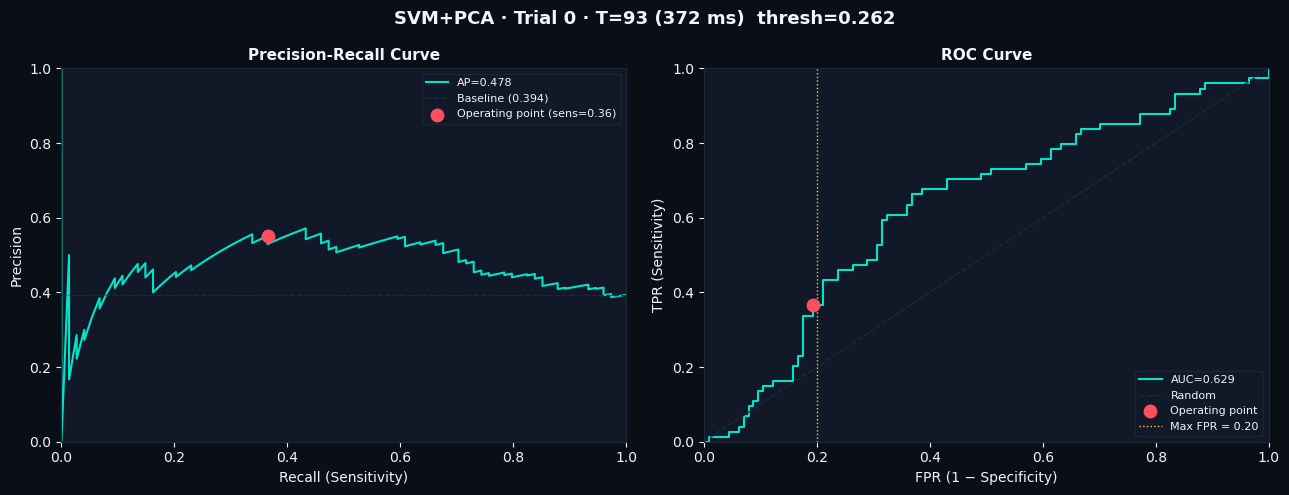

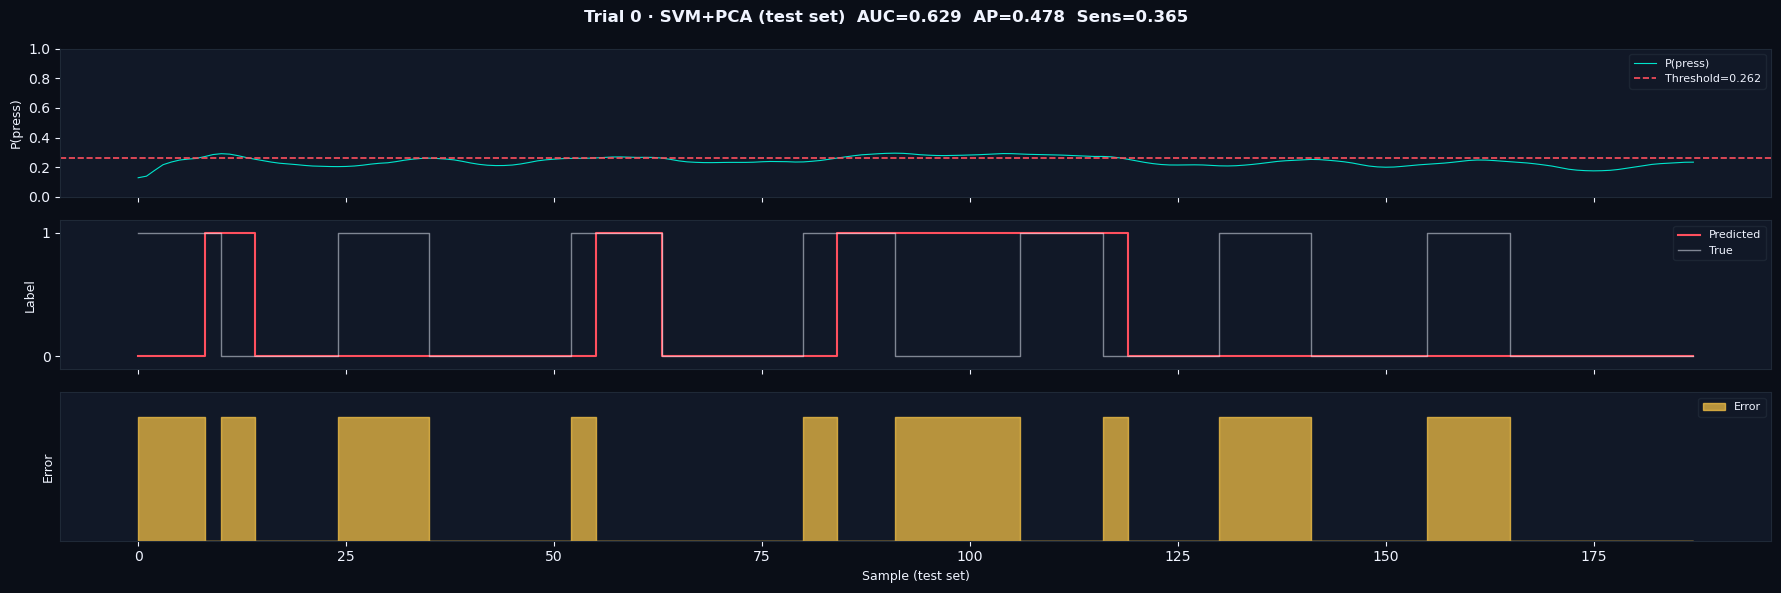

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
t_axis = np.arange(len(probs_test_smooth))

ax = axes[0]
ax.set_facecolor(CARD)
ax.plot(t_axis, probs_test_smooth, color=TEAL, lw=0.8, label="P(press)")
ax.axhline(thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold={thresh:.3f}")
ax.set_ylim(0, 1)
ax.set_ylabel("P(press)", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)

ax = axes[1]
ax.set_facecolor(CARD)
ax.plot(t_axis, preds_smooth, drawstyle="steps-post", color=CORAL, lw=1.5, label="Predicted")
ax.plot(t_axis, y_test,       drawstyle="steps-post", color=WHITE, lw=1.0, alpha=0.5, label="True")
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_ylabel("Label", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)

ax = axes[2]
ax.set_facecolor(CARD)
errors = (preds_smooth != y_test).astype(float)
ax.fill_between(t_axis, errors, color=GOLD, alpha=0.7, step="post", label="Error")
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_ylabel("Error", color=WHITE, fontsize=9)
ax.set_xlabel("Sample (test set)", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)

fig.suptitle(
    f"Trial {TRIAL} · SVM+PCA (test set)  "
    f"AUC={auc_smooth:.3f}  AP={ap_smooth:.3f}  Sens={sensitivity:.3f}",
    color=WHITE, fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

## 13 · PCA Analysis

Explained variance per component + the top-2 principal components reshaped  
to `(C, T)` — reveals which channels and time lags drive variance.

In [13]:
pca = best_pipe["pca"]
ev  = pca.explained_variance_ratio_
ev_cum = np.cumsum(ev)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=DARK)

# ── Scree plot ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_color(EDGE)
ax.bar(range(1, len(ev)+1), ev*100, color=TEAL, alpha=0.8, edgecolor=EDGE)
ax2 = ax.twinx()
ax2.plot(range(1, len(ev)+1), ev_cum*100, color=CORAL, lw=2)
ax2.axhline(90, color=GOLD, lw=1, ls="--", label="90%")
ax2.set_ylabel("Cumulative %", color=CORAL, fontsize=9)
ax2.tick_params(colors=CORAL)
ax.set_xlabel("Component", color=WHITE, fontsize=9)
ax.set_ylabel("Explained variance %", color=WHITE, fontsize=9)
ax.set_title("Scree Plot", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)

# ── PC1 heatmap (C × T) ───────────────────────────────────────────────────
for pc_idx, ax in zip([0, 1], axes[1:]):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values(): sp.set_color(EDGE)
    # components_ shape: (n_components, C*T) — flatten order is (T,C) from build_windows
    pc = pca.components_[pc_idx].reshape(T, N_CHANNELS).T  # → (C, T)
    vmax = np.abs(pc).max()
    im = ax.imshow(pc, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    plt.colorbar(im, ax=ax)
    ax.set_yticks(range(N_CHANNELS))
    ax.set_yticklabels(EEG_COLS, color=WHITE, fontsize=8)
    ax.set_xlabel("Lag (samples, 0=oldest)", color=WHITE, fontsize=9)
    ax.set_title(f"PC{pc_idx+1}  ({ev[pc_idx]*100:.1f}% var)",
                 color=WHITE, fontsize=11, fontweight="bold")
    ax.tick_params(colors=WHITE)

plt.suptitle("PCA Components — Channel × Temporal Lag",
             color=WHITE, fontsize=13, fontweight="bold")
plt.tight_layout()

## 14 · Optuna Search History

In [14]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values(): sp.set_color(EDGE)

trials_df = study.trials_dataframe(attrs=("number", "value", "state"))
comp = trials_df[trials_df["state"] == "COMPLETE"].sort_values("number")
vals = comp["value"].values
nums = comp["number"].values
best_so_far = np.maximum.accumulate(vals)

ax.scatter(nums, vals, color=TEAL, alpha=0.5, s=30, zorder=3, label="Trial AUC")
ax.plot(nums, best_so_far, color=GOLD, lw=2.5, zorder=4, label="Best so far")
ax.axhline(best_so_far[-1], color=CORAL, lw=1.0, ls="--",
           label=f"Best={best_so_far[-1]:.4f}")
ax.set_xlabel("Trial", color=WHITE, fontsize=10)
ax.set_ylabel("Validation AUC", color=WHITE, fontsize=10)
ax.set_title("Optuna Search History", color=WHITE, fontsize=12, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)
plt.tight_layout()

## 15 · Save Model

In [15]:
SAVE_PATH = f"../data/subject{SUBJECT}/model_svm_trial{TRIAL}"
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(best_pipe, f"{SAVE_PATH}/eeg_svm_pipeline.joblib")

params_to_save = {
    "trial":          int(TRIAL),
    "T":              int(T),
    "n_components":   int(n_components),
    "explained_var":  float(explained),
    "kernel":         kernel,
    "C":              float(C),
    "gamma":          gamma,
    "class_weight":   class_weight,
    "optuna_cv_auc":  float(study.best_value),
    "test_auc":       float(auc_test),
    "test_auc_smooth": float(auc_smooth),
    "test_ap_smooth": float(ap_smooth),
    "best_thresh":    float(thresh),
    "sensitivity":    float(sensitivity),
    "specificity":    float(specificity),
    "smooth_window":  int(SMOOTH_WINDOW),
    "min_specificity": float(MIN_SPECIFICITY),
    "n_channels":     int(N_CHANNELS),
    "channel_names":  EEG_COLS,
    "fs":             int(FS),
    "train_frac":     float(TRAIN_FRAC),
    "per_window_norm": True,
}
with open(f"{SAVE_PATH}/eeg_svm_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)

print("Saved:")
print(f"  {SAVE_PATH}/eeg_svm_pipeline.joblib")
print(f"  {SAVE_PATH}/eeg_svm_params.json")
print(f"\nKey metrics: AUC={auc_smooth:.4f}  AP={ap_smooth:.4f}  sens={sensitivity:.4f}  spec={specificity:.4f}")

Saved:
  ../data/subject9/model_svm_trial0/eeg_svm_pipeline.joblib
  ../data/subject9/model_svm_trial0/eeg_svm_params.json

Key metrics: AUC=0.6293  AP=0.4781  sens=0.3649  spec=0.8070


In [16]:
print("Loading new trial …")
AUCs = []

for TRIAL in range(1, 9):

    df, EEG_COLS = load_trial(SUBJECT, TACHE, TRIAL, DATA_PATH, lp=LP, hp=HP, decimate=DECIM)
    X_raw = df[EEG_COLS].values.astype(np.float32)
    y_raw = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    N_CHANNELS = len(EEG_COLS)
    
    n_press = int(y_raw.sum())
    print(f"Trial {TRIAL}: {len(df):,} samples  (FS_EFF={FS_EFF} Hz)")
    print(f"  horizon-press : {n_press:,} ({n_press/len(df)*100:.1f}%)")
    print(f"  no-press      : {int((y_raw==0).sum()):,}")
    print(f"  channels      : {N_CHANNELS}  {EEG_COLS}")
    
    X_win, y_win = build_windows(X_raw, y_raw, T, stride=STRIDE)  # (M, C*T) flat
    M = len(y_win)
    n_press_w = int(y_win.sum())
    
    print(f"Windows  : {M:,}  (each window = {N_CHANNELS} ch × {T} lags = {N_CHANNELS*T} features)")
    print(f"  press    : {n_press_w:,} ({n_press_w/M*100:.1f}%)")
    print(f"  no-press : {M - n_press_w:,}")
    print(f"  memory   : {X_win.nbytes/1e6:.1f} MB")


    probs_test_new = best_pipe.predict_proba(X_win)[:, 1]
    preds_test_new = (probs_test_new >= 0.5).astype(int)
    auc_test_new   = roc_auc_score(y_win, probs_test_new)
    ap_test_new    = average_precision_score(y_win, probs_test_new)
    
    print(f"Test AUC : {auc_test_new:.4f}")
    print(f"Test AP  : {ap_test_new:.4f}")
    print(f"Accuracy : {(preds_test_new == y_win).mean():.4f}  (@threshold=0.5)")
    print()
    print(classification_report(y_win, preds_test_new, target_names=["Not pressed", "Pressed"]))

    AUCs.append( auc_test_new )

Loading new trial …
Setting up band-pass filter from 0.5 - 8 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


- Windowed time-domain design (firwin) method


...

- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


- Upper passband edge: 8.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)


- Filter length: 1651 samples (6.604 s)


Trial 8: 3,750 samples  (FS_EFF=62 Hz)
  horizon-press : 2,493 (66.5%)
  no-press      : 1,257
  channels      : 16  ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']
Windows  : 458  (each window = 16 ch × 93 lags = 1488 features)
  press    : 311 (67.9%)
  no-press : 147
  memory   : 2.7 MB
Test AUC : 0.4538
Test AP  : 0.6327
Accuracy : 0.3210  (@threshold=0.5)

              precision    recall  f1-score   support

 Not pressed       0.32      1.00      0.49       147
     Pressed       0.00      0.00      0.00       311

    accuracy                           0.32       458
   macro avg       0.16      0.50      0.24       458
weighted avg       0.10      0.32      0.16       458



In [17]:
plt.plot( AUCs , "o-" )

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
t_axis = np.arange(len(preds_test_new))

ax = axes
ax.set_facecolor(CARD)
ax.plot(t_axis, probs_test_new, color=TEAL, lw=0.8, label="P(press)")
ax.plot(t_axis, y_win / 2, color="w", lw=0.8, label="Presses")

ax.set_ylim(0, 1)
ax.set_ylabel("P(press)", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)




In [19]:
T

93